# Solar PV Module Access

RESKit simulates different PV modules. To see which modules are available, have a look at this example.

Workflow:
1. Import required packages
2. Import PV module parameter from PVLib
3. Load system advisor model from PVLib
4. Simulation with chosen PV module

In [7]:
import reskit as rk
import pvlib
import pandas as pd

Import first module's parameter from PVLib

In [8]:
# Access Modules from PVLib
n = 0
pvlib.pvsystem.retrieve_sam("CECMod").T.iloc[n : n + 1]

,Technology,Bifacial,STC,PTC,A_c,Length,Width,N_s,I_sc_ref,V_oc_ref,...,a_ref,I_L_ref,I_o_ref,R_s,R_sh_ref,Adjust,gamma_r,BIPV,Version,Date
A10Green_Technology_A10J_S72_175,Mono-c-Si,0,175.0914,151.2,1.3,1.576,0.825,72,5.17,43.99,...,1.981696,5.175703,0.0,0.316688,287.102203,16.057121,-0.5072,N,SAM 2018.11.11 r2,1/3/2019


Load system advisor model (SAM) from PVLib and print it 

In [9]:
# Access Single Modules
df_modules = pvlib.pvsystem.retrieve_sam("CECMod")
print(df_modules)

           A10Green_Technology_A10J_S72_175 A10Green_Technology_A10J_S72_180  \
Technology                        Mono-c-Si                        Mono-c-Si   
Bifacial                                  0                                0   
STC                                175.0914                          179.928   
PTC                                   151.2                            155.7   
A_c                                     1.3                              1.3   
Length                                1.576                            1.576   
Width                                 0.825                            0.825   
N_s                                      72                               72   
I_sc_ref                               5.17                             5.31   
V_oc_ref                              43.99                            44.06   
I_mp_ref                               4.78                              4.9   
V_mp_ref                              36

/fast/home/t-miosga/code/reskit/reskit/solar/workflows/solar_workflow_manager.py:1055: UserWarning: NOTE: The tech_year argument is ignored when a specific module is given. Set tech_year to None to silence this warning.
  warnings.warn(
/fast/home/t-miosga/code/reskit/reskit/weather/NCSource.py:258: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation

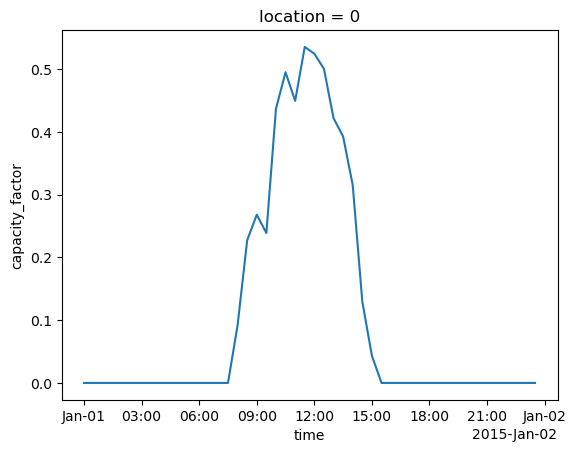

In [12]:
# Access Single Modules and use it in simulation

# Make a placements dataframe with one location
placements = pd.DataFrame()
placements["lon"] = [
    6.083,
]  # Longitude
placements["lat"] = [
    50.775,
]  # Latitude
placements["tilt"] = [
    32,
]  # System tilt in degrees
placements["azimuth"] = [
    180,
]  # System azimuth in degrees
placements["capacity"] = [
    2000,
 ]  # Total system capacity in kW
placements["elev"] = [
    250,
] # Altitude in meters

placements

out = rk.solar.openfield_pv_sarah_unvalidated(
    placements=placements,
    sarah_path=rk.TEST_DATA["sarah-like"],
    era5_path=rk.TEST_DATA["era5-like"],
    module="A10Green_Technology_A10J_S72_175",  # First PV module from database, which was accessed in the previous cell. You can change this to any other module from the database.
)
out.capacity_factor.plot()